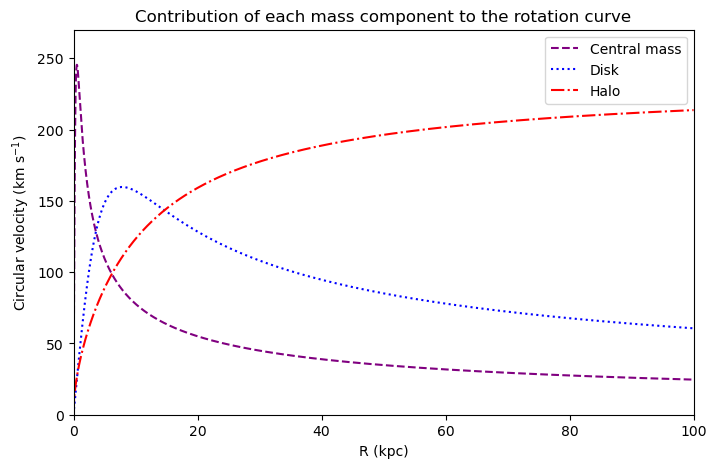

In [24]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.001,100,10000) # kpc units
y = np.linspace(0.001,100,10000)
z = np.zeros(10000)
#z = np.linspace(0.001,100,10000)


R = np.sqrt(x**2 + y**2 + z**2) # kpc units

# Central mass
M1 = 606.
b1 = 0.3873

dphi_x1 =  M1*x/(x**2 + y**2 + z**2 + b1**2)**(3/2)
dphi_y1 =  M1*y/(x**2 + y**2 + z**2 + b1**2)**(3/2)
dphi_z1 =  M1*z/(x**2 + y**2 + z**2 +b1**2)**(3/2) 

vel_c1 = np.sqrt(100*(dphi_x1*x + dphi_y1*y + dphi_z1*z)) # km/s

# Disk component
M2 = 3690.
a2 = 5.3178
b2 = 0.25

dphi_x2 = M2*x / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2)**(3/2)
dphi_y2 = M2*y / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2)**(3/2)
dphi_z2 = M2*(a2*z*1/np.sqrt(z**2 + b2**2) + z) / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2))**2)**(3/2)

vel_c2 = np.sqrt(100*(dphi_x2*x + dphi_y2*y + dphi_z2*2)) # km/s

# Halo
M3 = 4615.
a3 = 12.

a = -(1.02*M3*(x/R))*((R/a3)**2.02)
b = R*(1+(R/a3)**1.02)

c = (2.02*M3/(a3**2))*(R/a3)**(0.02)
d = 1/(1 + (R/a3)**1.02)

term1 = a/(b**2)
term2 = c*d*(x/R)**2
dphi_x3 = (term1 + term2)
dphi_y3 = dphi_x3
dphi_z3 = dphi_x3

vel_c3 = np.sqrt(100*(dphi_x3*x + dphi_y3*y + dphi_z3*z))

dphi_x = dphi_x1 + dphi_x2 + dphi_x3
dphi_y = dphi_y1 + dphi_y2 + dphi_y3

v = np.sqrt(dphi_x*x + dphi_y*y)*10
#v = vel_c1 + vel_c2 + vel_c3

plt.figure(figsize=(8, 5))
plt.plot(R, vel_c1, color = "purple", label = "Central mass", linestyle = "dashed")
plt.plot(R, vel_c2, color = "blue", label = "Disk", linestyle = "dotted")
plt.plot(R, vel_c3, color = "red", label = "Halo", linestyle = "dashdot")
plt.title("Contribution of each mass component to the rotation curve")
plt.xlabel("R (kpc)")
plt.ylabel("Circular velocity (km s$^{-1}$)")
plt.xlim(0,100)
plt.ylim(0,270)
plt.legend()
plt.show()

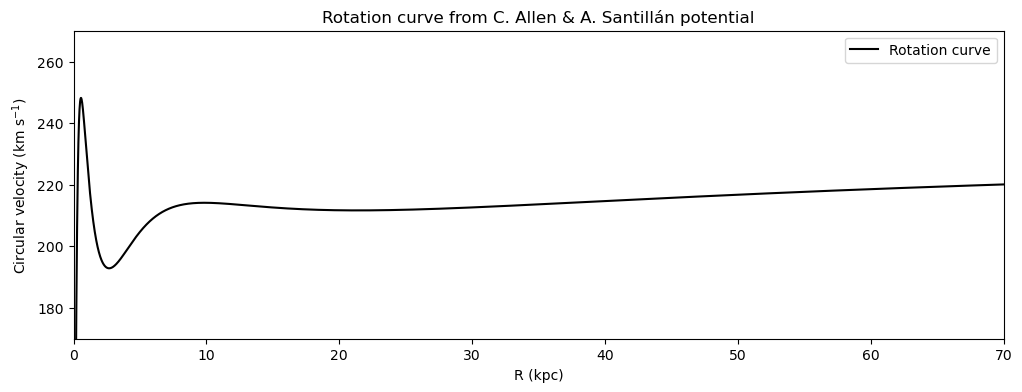

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(R, v, color = "k", label = "Rotation curve")
plt.xlabel("R (kpc)")
plt.ylabel("Circular velocity (km s$^{-1}$)")
plt.title("Rotation curve from C. Allen & A. Santillán potential")
plt.xlim(0,70)
plt.ylim(170,270)
plt.legend()
plt.show()